In [1]:
# step:1 Load the data
# step:2 Data -> Tensor
# step:3 Tensor dataset & Dataloader
# step:4 Define ANN model
# step:5 Train the model
# step:6 Evaluation

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# Here is means of labels:

# AT => temperature
# V => vacuum
# AP => pressure
# RH => Humidity

# PE => produced energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop('PE',axis=1)
y=df.PE

In [8]:
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
df.shape

(9568, 5)

In [11]:
# Standardize 
from sklearn.preprocessing import StandardScaler 

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting into tensors

In [13]:
import torch
import torch.nn as nn

In [14]:
X_train_tensors = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensors = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1) # view -1 bcz it autmatically replaced by the 7659 rows and 1 column.(converting the 2D array)


X_test_tensors = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensors = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# here is .values(bcz dtype is not same for both so pandas series can be access directly through the y_train)

In [15]:
# we are going to use ANN 
# 4 features
# 6 nuerons
# 1 predicted output

In [16]:
# Why multiple neurons?

# Imagine you're trying to predict the price of a house.

# One neuron learns:

# "Large area usually means higher price."

# Another learns:

# "Good location increases price."

# Another learns:

# "Older houses may be cheaper."

# Another learns:

# "Number of bedrooms matters."

In [17]:
from torch.utils.data import TensorDataset , DataLoader

trained_dataset = TensorDataset(X_train_tensors,y_train_tensors)
tested_dataset = TensorDataset(X_test_tensors,y_test_tensors)

trained_loader = DataLoader(trained_dataset,batch_size=32,shuffle=True)
tested_loader = DataLoader(tested_dataset,batch_size=32)


# Creating the ANN model

In [18]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()    # Here is constructor is called for accesing the module(Inheritance). go to my parents adn run his constructor.
    
        self.model = nn.Sequential(
            # 1st layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)
        
    

In [19]:
# since we are going to compute the LOSS and Optimizer.

In [20]:
import torch.optim as optim

model = ANN()

critrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [21]:
# Training the model
best_loss_score = float("inf")
epoch_val_loss = []
trained_epoch_losses = []
epochs = 100


for i in range(epochs):
    model.train()                  # First take you to the training mode after validation mode likewise.
    running_loss = 0.0             # Loss of 1 epoch

    for xb,yb in trained_loader:
                                   # xb = features of 1 batch
                                   # yb = labels of 1 batch
        optimizer.zero_grad()
        output = model(xb)          # Forward propagation
        loss = critrion(output,yb)  # Defining LOSS in between actual and predicted
        loss.backward()             # back prop...Compute gradients
        optimizer.step()            # changing the parameters
 
        running_loss += loss.item() # bcz it provides loss in tensors so we computes into the float value.

    epochs_train_loss = running_loss / len(trained_loader) 
    trained_epoch_losses.append(epochs_train_loss)


# Validation 
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():           # no gradient will be computed only works on saved gradients by [ nn.Module ]
        for xb,yb in tested_loader:
            output = model(xb)
            loss = critrion(output,yb)
            running_val_loss += loss
            
    epochs_validation_loss = running_val_loss/len(tested_loader)
    epoch_val_loss.append(epochs_validation_loss)

    if epochs_validation_loss < best_loss_score:
        best_loss_score = epochs_validation_loss
        torch.save(model.state_dict(),'best_parameters.pt')


    print(f"epoch {i+1}/{epochs} ==> trained loss = {epochs_train_loss} & val_loss = {epochs_validation_loss}")

epoch 1/100 ==> trained loss = 205944.60364583333 & val_loss = 204424.015625
epoch 2/100 ==> trained loss = 199036.2353515625 & val_loss = 189162.59375
epoch 3/100 ==> trained loss = 170803.941796875 & val_loss = 147461.703125
epoch 4/100 ==> trained loss = 119587.08020833334 & val_loss = 90446.7890625
epoch 5/100 ==> trained loss = 65996.47425130209 & val_loss = 45113.18359375
epoch 6/100 ==> trained loss = 33000.11138509114 & val_loss = 24623.17578125
epoch 7/100 ==> trained loss = 20438.674641927082 & val_loss = 17722.720703125
epoch 8/100 ==> trained loss = 15586.636682128907 & val_loss = 14076.205078125
epoch 9/100 ==> trained loss = 12420.226147460937 & val_loss = 11141.7724609375
epoch 10/100 ==> trained loss = 9733.052315266927 & val_loss = 8603.041015625
epoch 11/100 ==> trained loss = 7407.365072631836 & val_loss = 6416.8017578125
epoch 12/100 ==> trained loss = 5407.801064046224 & val_loss = 4611.166015625
epoch 13/100 ==> trained loss = 3798.68426361084 & val_loss = 3175.29

## Getting avg ( loss per epoch ) , we are going to divide batch_loss/ no. of batches

In [22]:
import matplotlib.pyplot as plt

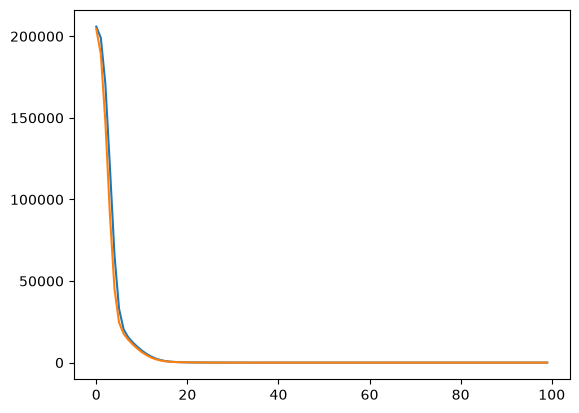

In [23]:
df = pd.DataFrame(
    {
        "Training_data": trained_epoch_losses,
        "Testing_data": epoch_val_loss,
    }
)

plt.plot(df["Training_data"],label='training data')
plt.plot(df["Testing_data"],label='Testing data')

In [24]:
model.load_state_dict(torch.load("best_parameters.pt"))   

# Here is we first loading the file (file_context:   all bias and weight values in raw file). now we 
# want to conclude the best parameters for our model so we are going going to fit this into the model. by load state dict.


# why we need this: suppose i work today and i want to use the same same weights

<All keys matched successfully>

In [28]:
# Evaluation part

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensors)
    test_pred = model(X_test_tensors)

    train_outs = critrion(train_pred,y_train_tensors)
    tst_outs = critrion(test_pred,y_test_tensors)

print(f"MSE => {train_outs}")
print(f"MSE => {tst_outs}")
print(f"MSE => {train_outs}")

MSE => 20.90148162841797
MSE => 19.28266143798828


In [33]:
from sklearn.metrics import r2_score

print(r2_score(train_pred,y_train_tensors))
print(r2_score(test_pred,y_test_tensors))

0.9233416318893433
0.9276471138000488


In [46]:
df1 = pd.DataFrame(train_pred,columns=['Predicted Output'])
df2 = pd.DataFrame(y_train_tensors,columns=['Actual Value'])

pd.concat([df1,df2],axis=1)

,Predicted Output,Actual Value
0,441.877014,442.750000
1,435.580017,432.519989
2,434.322144,428.799988
3,427.596527,426.070007
4,432.327209,436.579987
...,...,...
7649,439.730835,436.440002
7650,434.875610,441.200012
7651,461.768188,464.260010
7652,437.560913,440.450012
